In [1]:
import numpy as np
import math
import pylab
import matplotlib.pyplot as plt
import glob
from tqdm import tqdm

plotwidth = 25
plotheight = 20

In [11]:
def integration(x,y):
    suma = 0
    for i in range(0,len(x) - 2):
        actSum = 0.5 * (x[i] - x[i + 1]) * (y[i] + y[i + 1])
        suma += actSum
    return suma

# data from my model
data = np.loadtxt('./3DwindTestFullMA/spec.dat')


x = data[:,0]
y = data[:,1]

print(x, y)

vysledek = integration(x,y)
print (vysledek)

IOError: ./3DwindTestFullMA/spec.dat not found.

# Create a spectrum
This will calculate spectrum as the subroutine do_spectrum.f90 does

In [27]:
light_speed = 2.99792458E+10
ls_A = light_speed * 1.0E8
# bound wavelengths
wale_start = 500 # in Angstroms
wale_end = 20000 # in Angstroms
#recalculating it into the frequencies
nu_max = light_speed / (wale_start * 1.0E-8)
nu_min = light_speed / (wale_end * 1.0E-8)
# firstly the name of the file(s)
n_nubin = 10000 # number of frequency points
walespec = np.zeros((n_nubin,2))
delta_nu = (nu_max - nu_min) / float(n_nubin)


In [30]:
specFiles = "./3Dwind20190726143718/packet*.dat"
specFiles = "./3DWmacroatom_c/packet*.dat"
#specFiles = "./3DWdownbranch/packet*.dat"
# initialization of an array with informations about spectra
freqs = np.zeros(n_nubin)
# basic constants
def create_spectrum(inputfile, walespec, specflux): 
    # reading data from this file
    data = np.genfromtxt(inputfile)
    n_rows = data.shape[0]
    # print data[:,0]
    # num_rows = float((n_rows))
    with tqdm(total=n_rows) as pbar:
        for I in range (n_rows):
            pbar.update(1)
            if data[I,0] == -99:
                freq = data[I,1]
                if freq >= nu_min and freq <= nu_max:
                    nubin = ((freq - nu_min) / delta_nu) - 1
                    delta_e = data[I,2] / delta_nu 
                    specflux[int(nubin)] += delta_e


# Vygenerování spektra
specflux = np.zeros(n_nubin)   
# 
files = glob.glob(specFiles)
files.sort()
print(files)

for I in range (n_nubin):
        freqs[I] = nu_min + float(I - 1) * delta_nu

for photonfile in files:
    create_spectrum(photonfile, walespec, specflux)

# recalculation on wavelengths
for I in range(n_nubin):
    wavelength = ls_A / freqs[I]
    flambda = specflux[I] * (ls_A / wavelength**2)
    walespec[I,0] = wavelength
    walespec[I,1] = flambda
    

walespec[:,1] = walespec[:,1] / float(len(files))


['./3DWmacroatom_c/packet000.dat', './3DWmacroatom_c/packet001.dat', './3DWmacroatom_c/packet002.dat']


100%|██████████| 3000000/3000000 [00:08<00:00, 341890.43it/s]


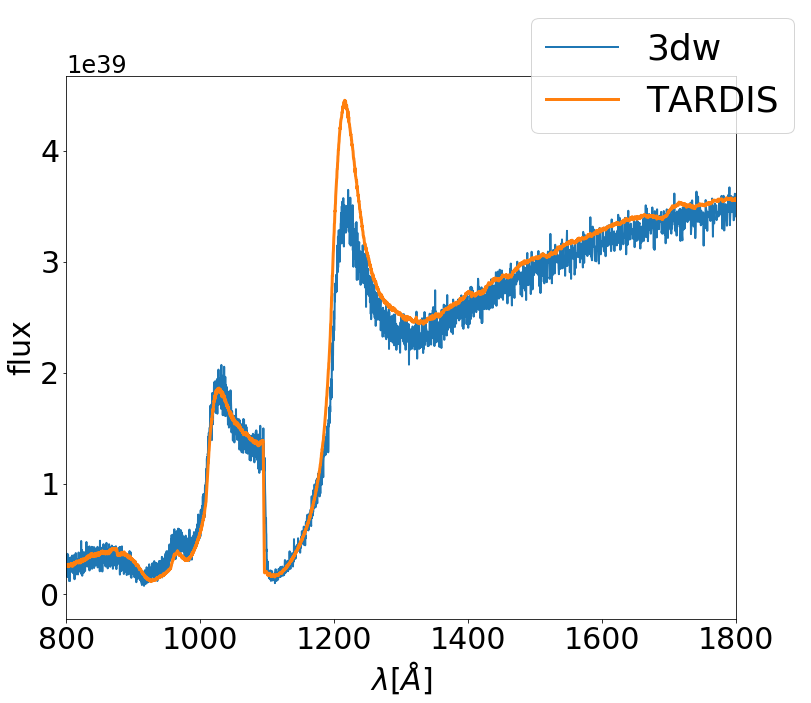

In [31]:
plotwidth = 25
plotheight = 20

# axes limits
# xmin = 0
xmin = 800
# xmin = 4000
#xmax = 2500
xmax = 1800
# xmin = wale_start
# xmax = 4800


# save file name
savefilename = 'spectrum_2.png'

tardisfile = './tc_macroatom.dat'
tardisdata = np.genfromtxt(tardisfile)

fig, ax = plt.subplots(figsize=(plotwidth / 2, plotheight / 2))
ax.plot(walespec[:,0], walespec[:,1], linewidth=2.0, label="3dw")
ax.plot(tardisdata[:,0], tardisdata[:,1], linewidth=3.0, label="TARDIS")
ax.set_xlim(xmin, xmax)
ax.tick_params(axis='both', which='major', labelsize=30)
ax.yaxis.offsetText.set_fontsize(24)
fig.legend(loc=1, prop={'size': 36})
ax.set_xlabel("$\lambda [\AA ]$", fontsize = 30)
ax.set_ylabel("flux", fontsize = 30)
fig.savefig(savefilename)

# pylab.plot(walespec[:,0], walespec[:,1], linewidth=2.0, label="3dw")
# pylab.plot(tardisdata[:,0], tardisdata[:,1], linewidth=3.0, label="TARDIS")
# plt.xlim(xmin,xmax)
# plt.tick_params(axis='both', which='major', labelsize=30)
# plt.tick_params(axis='both', which='minor', labelsize=30)
# #plt.yaxis.offsetText.set_fontsize(24)
# plt.rcParams['figure.figsize'] = [plotwidth, plotheight]
# pylab.xlabel("$\lambda [\AA ]$", fontsize = 50)
# pylab.ylabel("flux", fontsize = 50)
# #pylab.
# pylab.legend(loc=1, prop={'size': 36})
# pylab.savefig(savefilename)
# pylab.show()

In [20]:
# initialization of an array with informations about spectra
light_speed = 2.99792458E+10
ls_A = light_speed * 1.0E8
# bound wavelengths
wale_start = 500 # in Angstroms
wale_end = 10000 # in Angstroms
#recalculating it into the frequencies
nu_max = light_speed / (wale_start * 1.0E-8)
nu_min = light_speed / (wale_end * 1.0E-8)
# firstly the name of the file(s)
n_nubin = 5000 # number of frequency points

delta_nu = (nu_max - nu_min) / float(n_nubin)

# basic constants
def create_spectrum(inputfile, walespec, specflux): 
    # reading data from this file
    data = np.genfromtxt(inputfile)
    n_rows = data.shape[0]
    # print data[:,0]
    # num_rows = float((n_rows))
    with tqdm(total=n_rows) as pbar:
        for I in range (n_rows):
            pbar.update(1)
            if data[I,0] == -99:
                freq = data[I,1]
                if freq >= nu_min and freq <= nu_max:
                    nubin = ((freq - nu_min) / delta_nu) - 1
                    delta_e = data[I,2] / delta_nu 
                    specflux[int(nubin)] += delta_e

In [21]:
def specCalc(folders):
    spectra = []
    for cur_folder in folders:
        print("cur_folder:", cur_folder)
        freqs = np.zeros(n_nubin)
        walespec = np.zeros((n_nubin,2))
        specflux = np.zeros(n_nubin)  
        filename = "./" + cur_folder + "/packet*.dat"
        pack_files = glob.glob(filename)
        pack_files.sort()

        print(pack_files)

        for I in range (n_nubin):
                freqs[I] = nu_min + float(I - 1) * delta_nu

        for photonfile in pack_files:
            create_spectrum(photonfile, walespec, specflux)

        # recalculation on wavelengths
        for I in range(n_nubin):
            wavelength = ls_A / freqs[I]
            flambda = specflux[I] * (ls_A / wavelength**2)
            walespec[I,0] = wavelength
            walespec[I,1] = flambda


        walespec[:,1] = walespec[:,1] / float(len(pack_files))

        spectra.append(walespec)
    return spectra
# print(files)
# for file in files:
    # print(file)

In [22]:
def create_graph(spectras, minimalx, maximalx):
    fig, ax = plt.subplots(figsize=(plotwidth / 2, plotheight / 2))
    ax.set_xlim(minimalx, maximalx)
    ax.tick_params(axis='both', which='major', labelsize=30)
    ax.yaxis.offsetText.set_fontsize(24)
    ax.set_xlabel("$\lambda [\AA ]$", fontsize = 30)
    ax.set_ylabel("flux", fontsize = 30)

    labels = (["1", "2", "3", "4", "5", "6", "7", "8", "9", "10"])

    I = 0
    for cur_spec in spectras:
        # cur_folder = folders[I]
        # ax.plot(cur_spec[:,0], cur_spec[:,1], linewidth=2.0, label=cur_folder)
        ax.plot(cur_spec[:,0], cur_spec[:,1], linewidth=2.0, label=labels[I])
        I += 1

    fig.legend(loc=1, prop={'size': 30})
    fig.savefig('halpha_02.png')

In [23]:
slozky = (["3DWmacroatom", "3DWmacroatom_c"])

spectrum = specCalc(slozky)

('cur_folder:', '3DWmacroatom')
['./3DWmacroatom/packet000.dat', './3DWmacroatom/packet001.dat', './3DWmacroatom/packet002.dat']


100%|██████████| 3000000/3000000 [00:08<00:00, 349987.41it/s]


('cur_folder:', '3DWmacroatom_c')
['./3DWmacroatom_c/packet000.dat', './3DWmacroatom_c/packet001.dat', './3DWmacroatom_c/packet002.dat']


100%|██████████| 3000000/3000000 [00:08<00:00, 348004.79it/s]


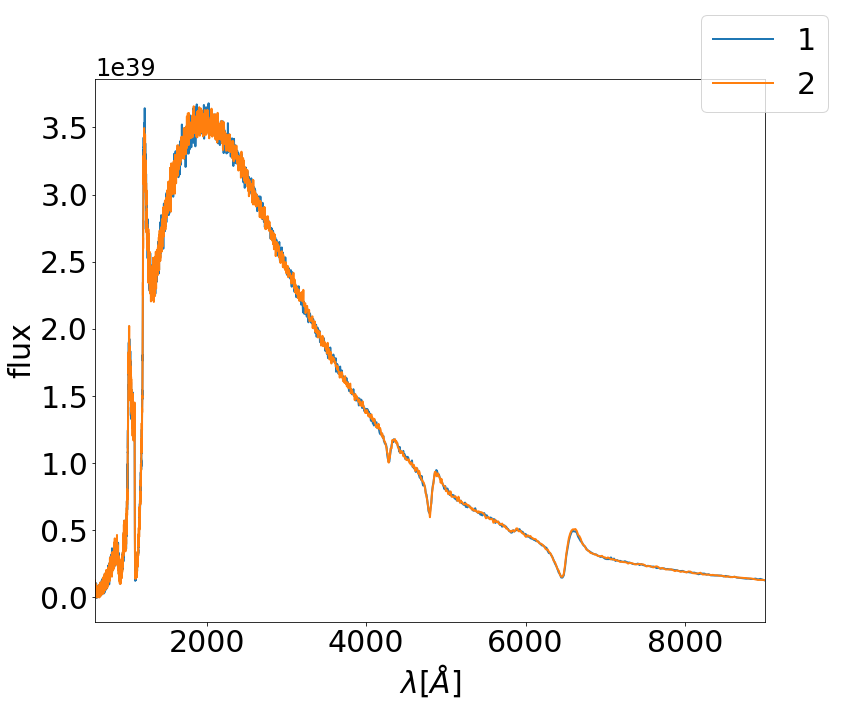

In [24]:
xmin = 600
xmax = 9000

create_graph(spectrum, xmin, xmax)

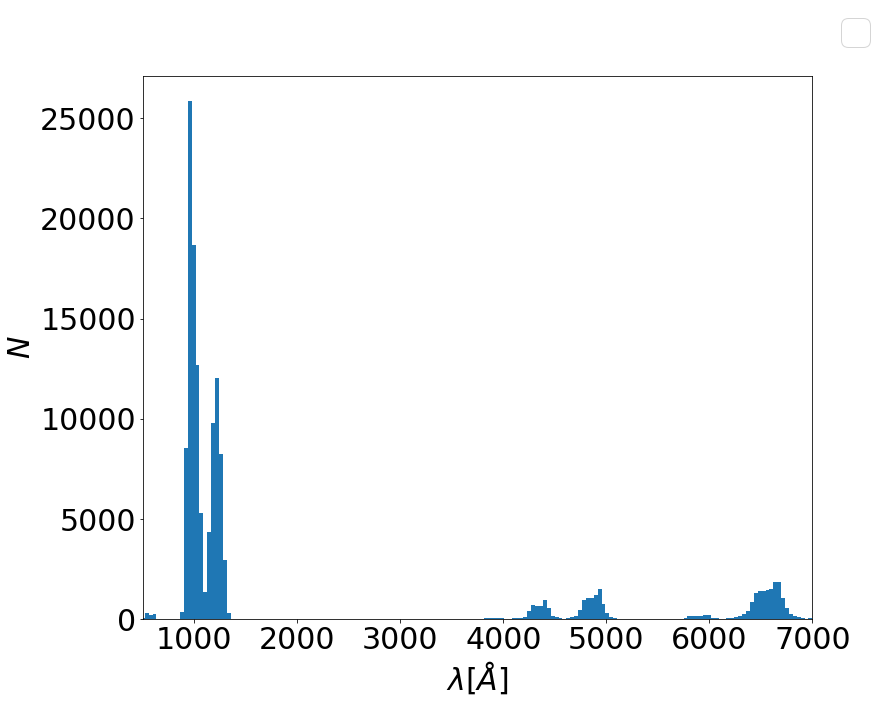

In [25]:
data = np.genfromtxt("fort.37")
xmin = 500
xmax = 7000


fig, ax = plt.subplots(figsize=(plotwidth / 2, plotheight / 2))
ax.set_xlim(xmin, xmax)
ax.tick_params(axis='both', which='major', labelsize=30)
ax.yaxis.offsetText.set_fontsize(24)
fig.legend(loc=1, prop={'size': 36})
ax.set_xlabel("$\lambda [\AA ]$", fontsize = 30)
ax.set_ylabel("$N$", fontsize = 30)

# ax.set_ylim(0, 100)
ax.hist(data, bins=2000)
fig.savefig('n_absorbed_cmf.eps')

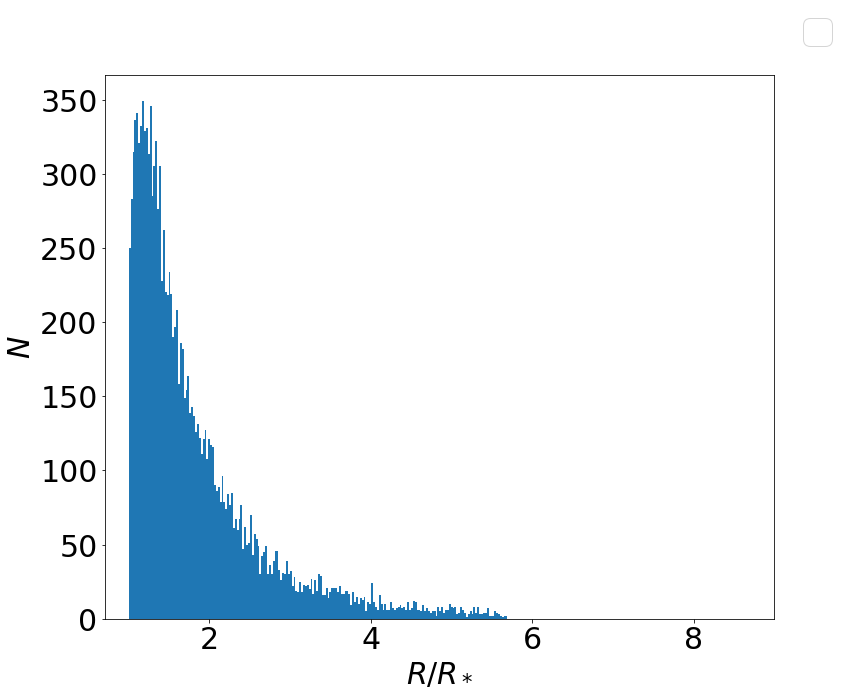

In [32]:
data = np.genfromtxt("fort.44")
xmin = 0.7
xmax = 9


fig, ax = plt.subplots(figsize=(plotwidth / 2, plotheight / 2))
ax.set_xlim(xmin, xmax)
ax.tick_params(axis='both', which='major', labelsize=30)
ax.yaxis.offsetText.set_fontsize(24)
fig.legend(loc=1, prop={'size': 36})
ax.set_xlabel("$R/R_*$", fontsize = 30)
ax.set_ylabel("$N$", fontsize = 30)

# ax.set_ylim(0, 100)
ax.hist(data, bins=200)
fig.savefig('intdist.eps')